# Chapter 26 — Meteor Scatter & Passive Radar (optional)

!!! info "Before you start"
    **Prerequisites:** Ch 5 (Hands-on SDR) · **Maths Lab:** [Lab B (Matched Filtering)](32_mathslab_matched_filtering.ipynb) · **~40 min** · **Intermediate**

> **This chapter is OPTIONAL and hardware-flavoured**, in the spirit of
> [Chapter 5 (Hands-on SDR)](05_sdr_basics.ipynb) and
> [Chapter 6 (Hydrogen Line)](06_hydrogen_line.ipynb). It points at one of the
> *cheapest and friendliest* real experiments in amateur radio astronomy:
> counting meteors by radio. You can do it for real with a \$30 RTL-SDR and a
> scrap of wire — but you need **no hardware and no network** to work through
> this chapter. Every cell runs end-to-end on the plain `jansky` base
> environment using the simulation in `jansky.meteor`. The one real-hardware
> recipe is clearly marked and never required.

When a meteoroid the size of a sand grain hits the upper atmosphere at tens of
kilometres per second, it *ablates*: it vaporises and ionises the air along its
path, leaving a thin column of free electrons ~80–120 km up. That column lasts a
fraction of a second to a few seconds — and while it lasts, it **reflects radio
waves**. Point a VHF receiver at a powerful transmitter that is *below your
horizon* (so you normally hear nothing), and each meteor trail briefly bounces
that transmitter into your antenna: a short **"ping."** This is **forward meteor
scatter**, and counting those pings over a night is a genuine, contributable
measurement — the meteor *rate*, which amateurs report to networks like the
[IMO](https://www.imo.net/) and [RMOB](http://www.rmob.org/).

## What you'll learn

- What **forward meteor scatter** is, and the two cheap ways amateurs do it:
  the **GRAVES** radar at **143.050 MHz** (Europe) and reflecting a distant
  **FM carrier** (worldwide).
- The two classic echo shapes — **underdense** (instant rise, exponential decay)
  and **overdense** (longer plateau) — and the physics that sets them.
- How to read **pings** in a power time series and a spectrogram, and how to
  **count** them with a threshold (the sensitivity-vs-false-alarm trade-off).
- Why the meteor **rate** over a night or a shower is the real scientific product.
- The neighbouring idea of **passive (bistatic) radar** — using a transmitter you
  don't control to detect aircraft or meteors — and where the open-source
  [`blah2`](https://github.com/30hours/blah2) receiver fits in.

This chapter connects directly to the SDR machinery of
[Chapter 5](05_sdr_basics.ipynb) (the spectrogram is the same `scipy.signal`
tool) and to the hardware field guide in
[`docs/projects.md`](../docs/projects.md) and
[`docs/field-notes.md`](../docs/field-notes.md).

## The setup (and the real-hardware path)

Forward scatter is *bistatic*: the transmitter (Tx) and your receiver (Rx) are in
different places, hundreds to ~2000 km apart, and a meteor trail at the midpoint
acts like a momentary mirror.

```
        meteor trail (ionised column, ~100 km up)
                 \  *  /
            Tx ───╳────── Rx      Tx is BELOW Rx's horizon:
       (GRAVES /     (you)        no direct signal, only meteor "pings"
        FM tower)
```

> **Real-hardware recipe (you do NOT need this to run the chapter).**
> Tune an **RTL-SDR** in narrow-band mode to a quiet frequency *just off* a
> strong distant carrier, point a small directional VHF antenna (a 3-element
> Yagi is plenty) up at the sky, and record the audio/power. Two proven targets:
>
> - **GRAVES (Europe), 143.050 MHz.** A French space-surveillance radar that
>   floodlights the sky. Tune ~143.049 MHz (a slight offset so a ping appears as
>   an audible tone) and watch for pings. See
>   [RTL-SDR.com: GRAVES meteors](https://www.rtl-sdr.com/using-the-graves-radar-to-listen-to-reflections-from-meteors-planes-and-spacecraft/).
> - **A distant FM carrier (worldwide).** No GRAVES nearby? Tune an unused
>   ~88 MHz FM frequency whose nearest user is hundreds of km away and point the
>   antenna up; meteors reflect that far transmitter into your receiver. See
>   [BAA: Meteor Reflections](https://britastro.org/section_information_/radio-astronomy-section-overview/radio-astronomy-basics/meteor-reflections).
>
> It is always legal to **listen** — radio astronomy is receive-only
> ([Field Notes](../docs/field-notes.md)). The catch from
> [Chapter 5](05_sdr_basics.ipynb) applies: the RTL-SDR's 8-bit ADC has tiny
> dynamic range, so a band-pass filter and pointing *away from* strong local FM
> help a lot.

Everything below uses the `jansky.meteor` simulation, so the whole chapter is
reproducible offline. We reuse its helpers rather than re-deriving them:
`underdense_echo`, `overdense_echo`, `simulate_meteor_timeseries`,
`detect_pings`, and the `MeteorDetection` result.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

from jansky import signals, plotting, meteor

plotting.use_jansky_style()

# Seed everything for reproducible figures. 143 -> the GRAVES band, in MHz.
SEED = 143
rng = signals.rng(SEED)

# The meteor helpers we will reuse throughout this chapter:
print("reusing jansky.meteor helpers:")
for name in ("underdense_echo", "overdense_echo",
             "simulate_meteor_timeseries", "detect_pings", "MeteorDetection"):
    print(f"   meteor.{name}")

# Is real SDR capture available? (Purely informational -- nothing below needs it.)
try:
    from rtlsdr import RtlSdr  # provided by `pyrtlsdr`, needs a real dongle
    HAVE_RTLSDR = True
except Exception as exc:
    RtlSdr = None
    HAVE_RTLSDR = False
    _why = exc

if HAVE_RTLSDR:
    print("\npyrtlsdr importable -- real GRAVES/FM capture *may* be possible.")
    print("(We still use the simulation so results are reproducible.)")
else:
    print(f"\npyrtlsdr not available -> using the SIMULATION (base env, no hardware).")
    print(f"   reason: {type(_why).__name__}: {_why}")

reusing jansky.meteor helpers:
   meteor.underdense_echo
   meteor.overdense_echo
   meteor.simulate_meteor_timeseries
   meteor.detect_pings
   meteor.MeteorDetection

pyrtlsdr not available -> using the SIMULATION (base env, no hardware).
   reason: ModuleNotFoundError: No module named 'rtlsdr'


## 2. Echo shapes — underdense vs overdense

What a single ping *looks like* depends on how much ionisation the meteor laid
down. The dividing line is the trail's **electron line density** $q$ (electrons
per metre); the natural break is near $q \approx 2\times10^{14}\ \mathrm{e^-/m}$.

### Underdense trails — the exponential decay

In a **faint (underdense)** trail the electrons are sparse enough that the radio
wave passes through and each electron scatters more or less independently. The
echo **rises essentially instantly** when the trail forms, then **decays
exponentially** as the column spreads out and the free electrons recombine and
diffuse away. The decay is set by **ambipolar diffusion** — electrons and ions
drift apart, smearing the sharp column until it no longer reflects coherently.
The received amplitude follows

$$ A(t) \;=\; A_0\,\exp\!\left(-\frac{t-t_0}{\tau}\right), \qquad
   \tau \;=\; \frac{\lambda^2}{16\pi^2 D}, $$

where $\lambda$ is the radio wavelength and $D$ is the **ambipolar diffusion
coefficient** (which grows with altitude as the air thins). At VHF, $\tau$ ranges
from milliseconds to about a second. This is exactly `meteor.underdense_echo`.

### Overdense trails — the plateau

In a **dense (overdense)** trail there are so many electrons that the column
behaves like a **solid metallic cylinder**: the wave can't penetrate, it
reflects off the *surface*, and it keeps reflecting until the expanding column's
critical density drops below the radio frequency. These echoes last **longer**
(up to many seconds for bright fireballs) and have a **ragged, roughly flat-topped
(plateau) envelope** rather than a clean exponential. That is
`meteor.overdense_echo`. Overdense trails are rarer (bright meteors are rare), so
in a typical record most pings are underdense.

Let's plot both helper functions.

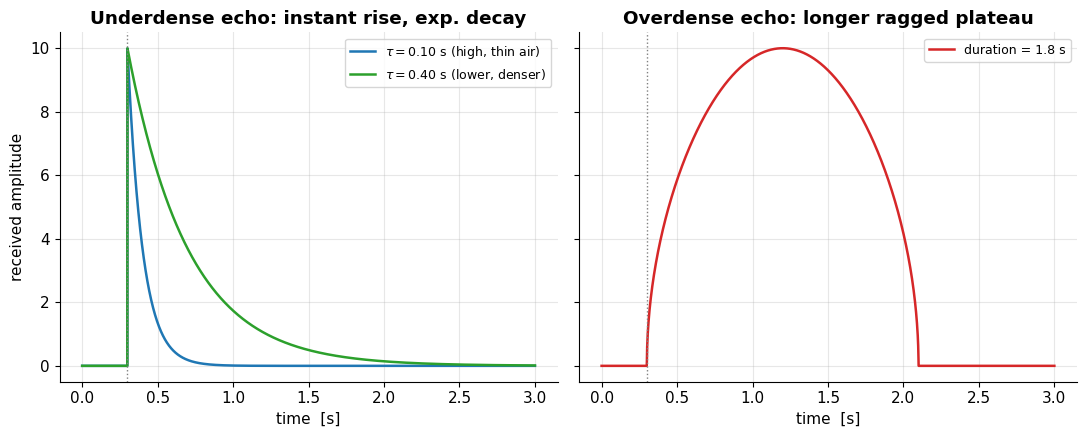

In [2]:
# A fine time axis for one ping, in seconds.
t = np.linspace(0, 3.0, 3000)

# Underdense: instant rise at t0, exponential decay (a few decay times shown).
u_fast = meteor.underdense_echo(t, t0=0.3, amplitude=10.0, decay_time=0.10)
u_slow = meteor.underdense_echo(t, t0=0.3, amplitude=10.0, decay_time=0.40)

# Overdense: a longer, ragged plateau of a given duration.
o_echo = meteor.overdense_echo(t, t0=0.3, amplitude=10.0, duration=1.8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

ax1.plot(t, u_fast, color="#1f77b4", lw=1.8, label=r"$\tau = 0.10$ s (high, thin air)")
ax1.plot(t, u_slow, color="#2ca02c", lw=1.8, label=r"$\tau = 0.40$ s (lower, denser)")
ax1.axvline(0.3, color="0.5", ls=":", lw=1)
ax1.set_title("Underdense echo: instant rise, exp. decay")
ax1.set_xlabel("time  [s]")
ax1.set_ylabel("received amplitude")
ax1.legend(fontsize=9)

ax2.plot(t, o_echo, color="#d62728", lw=1.8, label="duration = 1.8 s")
ax2.axvline(0.3, color="0.5", ls=":", lw=1)
ax2.set_title("Overdense echo: longer ragged plateau")
ax2.set_xlabel("time  [s]")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

The left panel shows two underdense echoes with different decay times $\tau$.
Both jump up the instant the trail forms, then fall off as $e^{-(t-t_0)/\tau}$.
Higher trails sit in thinner air where the diffusion coefficient $D$ is larger,
so they smear out *faster* (smaller $\tau$, blue); lower trails linger (green).
The right panel shows an overdense echo: it switches on, holds a rough plateau
for its full duration, then switches off — a qualitatively different shape that
betrays a much brighter meteor. In the next section we let
`simulate_meteor_timeseries` sprinkle a random mix of these into a noisy record.

## 3. A night of meteors — the power record

A real meteor monitor logs **received power vs time**, all night long. Meteors
arrive at random, so the number in any interval is **Poisson-distributed** about
a mean rate; the background between pings is receiver/sky noise (the radiometer
noise of [Chapter 3](03_signals_noise_radiometer.ipynb)).
`meteor.simulate_meteor_timeseries` builds exactly this: it lays down a Poisson
number of pings at a chosen mean **rate per minute**, draws each as an underdense
(80%) or overdense (20%) echo, and adds Gaussian noise. It returns the time axis,
the power, and the *true* ping times (our ground truth for the counting section).

We simulate a 2-minute stretch at a brisk ~30 meteors/minute so several pings are
visible at once.

In [3]:
# Simulate a 2-minute record. The helper seeds its own RNG for reproducibility.
DURATION_S = 120.0       # seconds (2 minutes)
RATE_PER_MIN = 30.0      # mean meteors per minute (Poisson)
SAMPLE_RATE = 100.0      # samples per second
NOISE = 1.0              # background noise sigma

times, power, true_pings = meteor.simulate_meteor_timeseries(
    duration_s=DURATION_S,
    rate_per_min=RATE_PER_MIN,
    sample_rate=SAMPLE_RATE,
    noise=NOISE,
    seed=SEED,
)

print(f"record length : {DURATION_S:.0f} s  ({times.size:,} samples @ {SAMPLE_RATE:.0f} Hz)")
print(f"mean rate set : {RATE_PER_MIN:.0f} meteors/min")
print(f"TRUE pings    : {true_pings.size}  (this realisation; Poisson scatter)")
print(f"expected mean : {RATE_PER_MIN * DURATION_S / 60:.0f}  (rate x minutes)")

record length : 120 s  (12,000 samples @ 100 Hz)
mean rate set : 30 meteors/min
TRUE pings    : 58  (this realisation; Poisson scatter)
expected mean : 60  (rate x minutes)


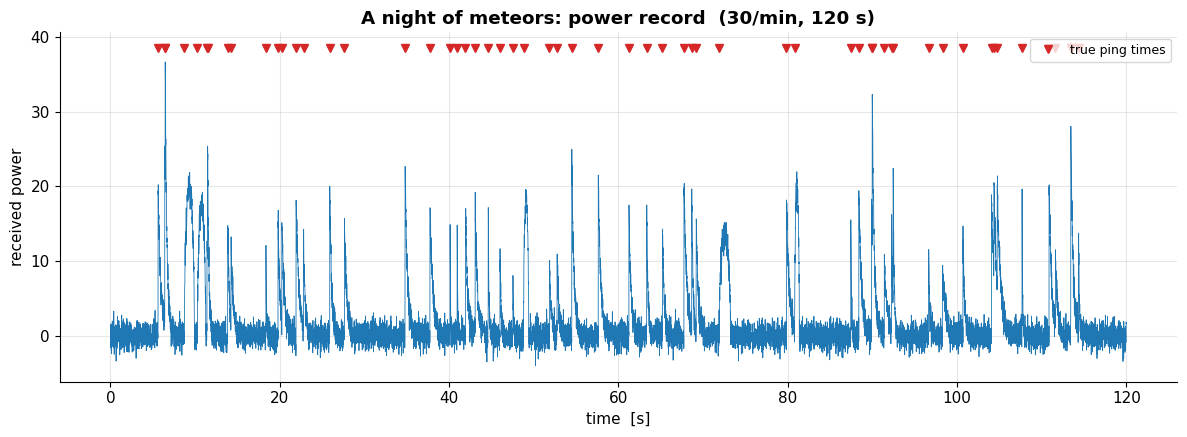

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(times, power, color="#1f77b4", lw=0.6)

# Mark the TRUE ping arrival times along the top.
ax.plot(true_pings, np.full_like(true_pings, power.max() * 1.05),
        "v", color="#d62728", ms=6, label="true ping times")

ax.set_xlabel("time  [s]")
ax.set_ylabel("received power")
ax.set_title(f"A night of meteors: power record  ({RATE_PER_MIN:.0f}/min, {DURATION_S:.0f} s)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

Each red marker is a real meteor. Most pings are the **underdense** spikes —
a sharp jump followed by a fast decay back into the noise. A handful are taller
and wider: those are the **overdense** plateaus from brighter meteors. The flat
band near the bottom is the noise floor; a ping has to poke clearly above it to
be counted, which is the whole problem of the next section.

### The spectrogram view

A real receiver records not just power but a *band*, so the natural display is the
same **waterfall / spectrogram** from [Chapter 5](05_sdr_basics.ipynb): time on
one axis, frequency on the other, brightness = power. To show what an operator
actually sees, we promote our power record to a narrow-band signal: model each
ping as the off-tuned **carrier tone** (a meteor reflecting GRAVES appears as a
short tone a few hundred Hz from your tuned frequency), amplitude-modulated by the
echo envelope, in complex noise. Then we hand it to `scipy.signal.spectrogram`.

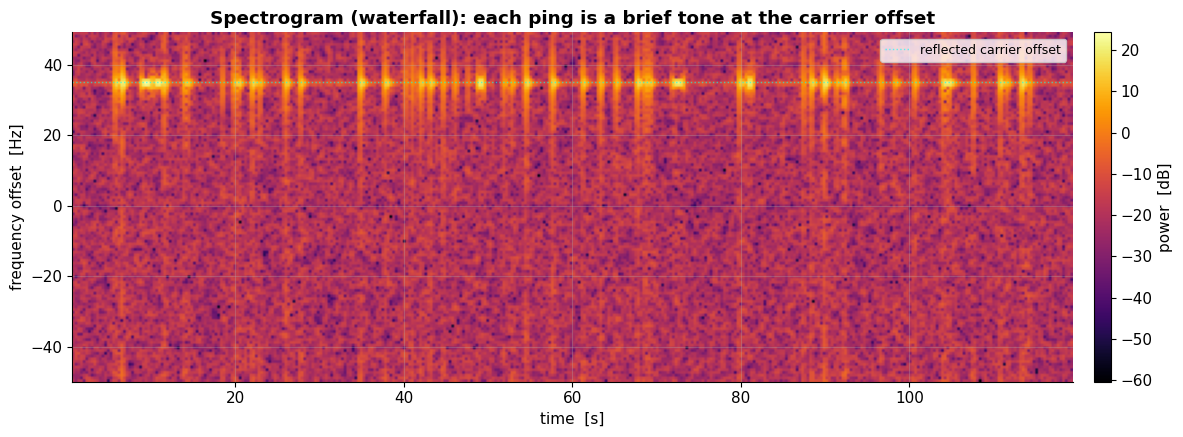

In [5]:
# Promote the power envelope to a narrow-band IQ signal so we can make a
# spectrogram exactly like Chapter 5. Each ping shows up as a short tone offset
# from the tuned frequency (here +350 Hz, a typical GRAVES audio offset).
fs_audio = SAMPLE_RATE
t_audio = times
carrier_offset = 35.0  # Hz offset of the reflected carrier from tuned freq

# Envelope = the (clipped) echo part of the power record above the noise.
envelope = np.clip(power, 0, None)
iq_audio = envelope * np.exp(1j * 2 * np.pi * carrier_offset * t_audio)
# Add complex baseband noise.
g = signals.rng(SEED)
iq_audio += (g.normal(0, NOISE, t_audio.size)
             + 1j * g.normal(0, NOISE, t_audio.size)) / np.sqrt(2)

f_spec, t_spec, Sxx = sig.spectrogram(
    iq_audio, fs=fs_audio, window="hann",
    nperseg=128, noverlap=96, return_onesided=False, scaling="density",
)
f_spec = np.fft.fftshift(f_spec)
Sxx = np.fft.fftshift(Sxx, axes=0)
Sxx_db = 10 * np.log10(Sxx + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4.5))
extent = [t_spec[0], t_spec[-1], f_spec[0], f_spec[-1]]
im = ax.imshow(Sxx_db, aspect="auto", extent=extent, origin="lower", cmap="inferno")
ax.axhline(carrier_offset, color="cyan", ls=":", lw=1, alpha=0.6,
           label="reflected carrier offset")
ax.set_xlabel("time  [s]")
ax.set_ylabel("frequency offset  [Hz]")
ax.set_title("Spectrogram (waterfall): each ping is a brief tone at the carrier offset")
ax.legend(loc="upper right", fontsize=9)
fig.colorbar(im, ax=ax, label="power  [dB]", fraction=0.030, pad=0.02)
fig.tight_layout()
plt.show()

Read it like the Chapter 5 waterfall: the meteor pings are the **bright
vertical dashes** sitting on the dotted carrier-offset line — short in time,
narrow in frequency. This is precisely what GRAVES monitoring software (e.g.
*Spectrum Lab*, *HROFFT*) shows; operators (and automatic counters) tally these
streaks. The power-vs-time plot and this waterfall are two views of the same
events. Now we count them automatically.

## 4. Counting them — detection and the threshold trade-off

To turn a wiggly power record into a *number*, we **threshold** it: a ping is any
excursion that rises more than $k$ noise-sigmas above the baseline. `detect_pings`
does this robustly — it estimates the noise level with the **median absolute
deviation (MAD)** (so a few huge pings don't inflate the noise estimate), finds
samples above `threshold` $\times \sigma$, and merges samples within
`min_separation_s` into a single event at its peak. It returns a `MeteorDetection`
with the detected times and count.

The only knob that matters is `threshold`. Set it **too low** and noise spikes get
counted as meteors (**false alarms**); set it **too high** and you miss the faint
underdense pings (**low sensitivity**). Let's run it at a sensible value and
compare to the truth.

In [6]:
THRESHOLD = 6.0   # in units of noise sigma (MAD estimate)

det = meteor.detect_pings(times, power, threshold=THRESHOLD, min_separation_s=0.3)
print(type(det).__name__, "->", "count =", det.count)

print(f"\nthreshold     : {THRESHOLD:.1f} sigma")
print(f"DETECTED pings: {det.count}")
print(f"TRUE pings    : {true_pings.size}")
print(f"difference    : {det.count - true_pings.size:+d}")

# Match detections to truth to estimate completeness & false-alarm rate.
TOL = 0.5  # s: a detection within TOL of a true ping counts as a real match
matched_true = 0
for tp in true_pings:
    if det.times.size and np.min(np.abs(det.times - tp)) < TOL:
        matched_true += 1
false_alarms = 0
for dt in det.times:
    if true_pings.size == 0 or np.min(np.abs(true_pings - dt)) >= TOL:
        false_alarms += 1

completeness = matched_true / true_pings.size if true_pings.size else 0.0
print(f"\ncompleteness  : {completeness:5.1%}  ({matched_true}/{true_pings.size} true pings recovered)")
print(f"false alarms  : {false_alarms}  (detections with no true ping nearby)")

MeteorDetection -> count = 48

threshold     : 6.0 sigma
DETECTED pings: 48
TRUE pings    : 58
difference    : -10

completeness  : 89.7%  (52/58 true pings recovered)
false alarms  : 2  (detections with no true ping nearby)


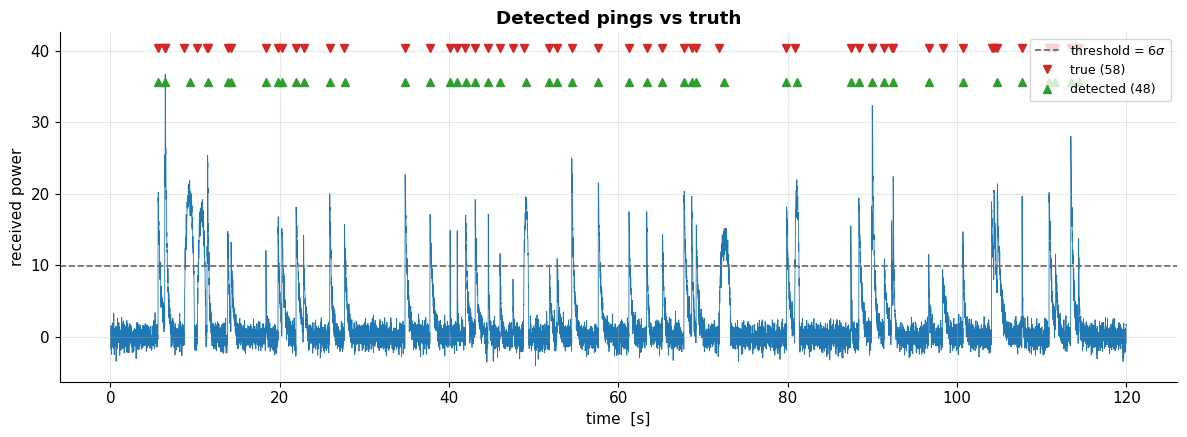

In [7]:
# Show the detections on the power record.
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(times, power, color="#1f77b4", lw=0.6, zorder=1)

# The robust threshold line that detect_pings effectively uses (MAD-based).
med = np.median(power)
mad = np.median(np.abs(power - med))
sigma = 1.4826 * mad
ax.axhline(med + THRESHOLD * sigma, color="0.4", ls="--", lw=1.2,
           label=f"threshold = {THRESHOLD:.0f}$\\sigma$")

ax.plot(true_pings, np.full_like(true_pings, power.max() * 1.10),
        "v", color="#d62728", ms=6, label=f"true ({true_pings.size})")
ax.plot(det.times, np.full_like(det.times, power.max() * 0.97),
        "^", color="#2ca02c", ms=6, label=f"detected ({det.count})")

ax.set_xlabel("time  [s]")
ax.set_ylabel("received power")
ax.set_title("Detected pings vs truth")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

### Sweeping the threshold

The trade-off becomes obvious if we sweep `threshold` and watch how the detected
count, the completeness, and the false alarms move. We expect: low thresholds
**over-count** (false alarms from noise), high thresholds **under-count** (missed
faint pings), and a broad sweet spot in between where the detected count tracks
the truth.

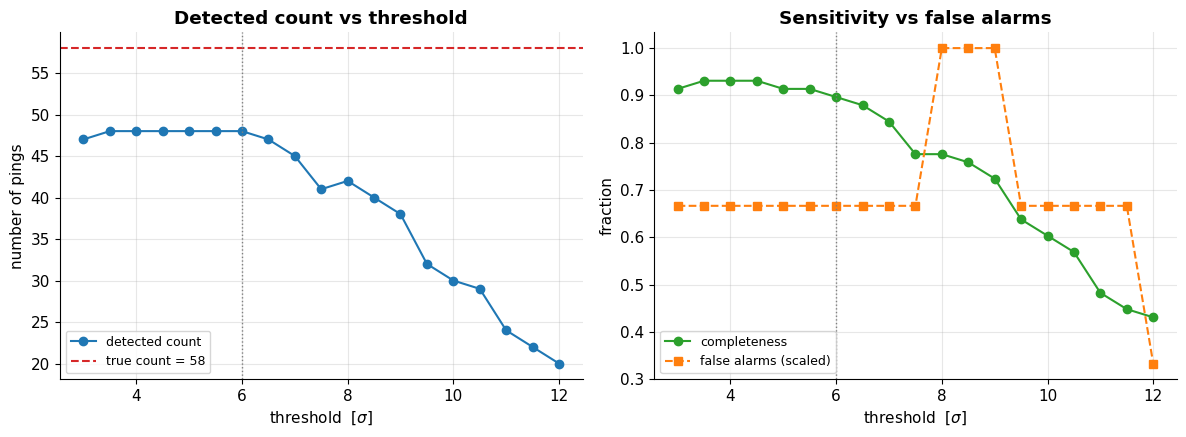

In [8]:
thresholds = np.arange(3.0, 12.1, 0.5)
counts, comps, fas = [], [], []

for th in thresholds:
    d = meteor.detect_pings(times, power, threshold=th, min_separation_s=0.3)
    counts.append(d.count)
    mt = sum(
        1 for tp in true_pings
        if d.times.size and np.min(np.abs(d.times - tp)) < TOL
    )
    fa = sum(
        1 for dt in d.times
        if true_pings.size == 0 or np.min(np.abs(true_pings - dt)) >= TOL
    )
    comps.append(mt / true_pings.size if true_pings.size else 0.0)
    fas.append(fa)

counts, comps, fas = map(np.asarray, (counts, comps, fas))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(thresholds, counts, "o-", color="#1f77b4", label="detected count")
ax1.axhline(true_pings.size, color="#d62728", ls="--", lw=1.5,
            label=f"true count = {true_pings.size}")
ax1.axvline(THRESHOLD, color="0.5", ls=":", lw=1)
ax1.set_xlabel(r"threshold  [$\sigma$]")
ax1.set_ylabel("number of pings")
ax1.set_title("Detected count vs threshold")
ax1.legend(fontsize=9)

ax2.plot(thresholds, comps, "o-", color="#2ca02c", label="completeness")
ax2.plot(thresholds, fas / max(fas.max(), 1), "s--", color="#ff7f0e",
         label="false alarms (scaled)")
ax2.axvline(THRESHOLD, color="0.5", ls=":", lw=1)
ax2.set_xlabel(r"threshold  [$\sigma$]")
ax2.set_ylabel("fraction")
ax2.set_title("Sensitivity vs false alarms")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

The picture is the classic detection trade-off. At **low thresholds** (left
of each plot) the detected count balloons above the true count: the detector is
firing on noise, so false alarms (orange) are high even though completeness
(green) is near 100%. At **high thresholds** the noise false alarms vanish but
completeness falls — the faintest underdense pings never clear the bar, so the
count drops *below* truth. In between, around **6$\sigma$**, the detected count
sits closest to the true count with few false alarms. There is no universally
"correct" threshold; you pick it for your noise level and how much you fear false
positives versus missed meteors — and then **keep it fixed** so your rates are
comparable night to night.

### The real product: meteor rate

A single count isn't the science — the **rate over time** is. Amateurs bin pings
per hour all through a night (and especially across a shower like the Perseids or
Geminids) and the rate curve, corrected for sensitivity, is what gets contributed
to networks like the [IMO Video Meteor Network](https://www.imo.net/) and
[RMOB](http://www.rmob.org/). Radio has a superpower here that optical lacks: it
**works in daylight and through cloud**, so radio is how the *daytime* meteor
showers (the Arietids, the $\zeta$-Perseids) are monitored at all. Let's turn our
detections into a rate.

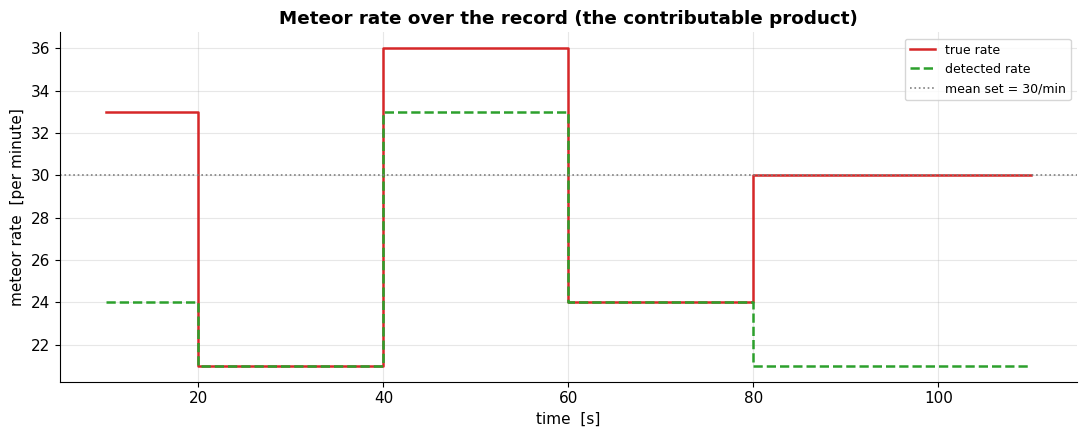

In [9]:
# Bin the detected pings into a rate (per minute) over the record.
bin_s = 20.0
edges = np.arange(0, DURATION_S + bin_s, bin_s)
det_hist, _ = np.histogram(det.times, bins=edges)
true_hist, _ = np.histogram(true_pings, bins=edges)
centers = 0.5 * (edges[:-1] + edges[1:])
to_per_min = 60.0 / bin_s

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.step(centers, true_hist * to_per_min, where="mid", color="#d62728",
        lw=1.8, label="true rate")
ax.step(centers, det_hist * to_per_min, where="mid", color="#2ca02c",
        lw=1.8, ls="--", label="detected rate")
ax.axhline(RATE_PER_MIN, color="0.5", ls=":", lw=1.2,
           label=f"mean set = {RATE_PER_MIN:.0f}/min")
ax.set_xlabel("time  [s]")
ax.set_ylabel("meteor rate  [per minute]")
ax.set_title("Meteor rate over the record (the contributable product)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The detected rate (green) tracks the true rate (red) and both scatter around
the mean we set (dotted) — that scatter is just Poisson counting statistics, the
fundamental noise of *any* rate measurement. Over a real night you would see this
curve climb during a shower's peak; the shape of that climb, the **zenithal hourly
rate**, is the headline number meteor astronomers care about.

## 5. Passive radar — a brief detour

Forward meteor scatter is one member of a bigger family: **passive (bistatic)
radar**, where you exploit a powerful transmitter *you don't own or control* — an
FM tower, a digital-TV transmitter, GRAVES — as your illuminator, and only ever
**receive**. A conventional radar transmits a pulse and times the echo; passive
radar instead listens with **two channels**:

- a **reference channel**, an antenna pointed at the illuminator to record a clean
  copy of the transmitted signal;
- a **surveillance channel**, an antenna pointed at the sky/airspace to catch the
  faint reflections off targets (aircraft, the Moon, ionised meteor trails).

You then **cross-correlate** the two channels. The correlation peaks at the **time
delay** of the echo (which gives the *bistatic range* — the extra path length via
the target) and at its **Doppler shift** (which gives the target's line-of-sight
velocity). Sweep delay vs Doppler and you get the **range–Doppler map** that
reveals each moving target as a blob. This needs **two coherent receivers** — the
same phase-coherence problem as amateur interferometry in
[Chapter 17](17_coherent_interferometry_kraken.ipynb) and
[Field Notes](../docs/field-notes.md) — which is why people use a dual-channel
dongle or a shared clock. The open-source **[`blah2`](https://github.com/30hours/blah2)**
receiver (see [`docs/field-notes.md`](../docs/field-notes.md)) implements exactly
this with two RTL-SDRs and an FM station, and will draw you a live range–Doppler
map of the aircraft overhead.

Here is the tiny piece of geometry that turns a measured **time delay** into a
**bistatic range** — no hardware, just arithmetic with `astropy` constants.

In [10]:
from astropy import constants as const, units as u

# Bistatic geometry: signal travels Tx -> target -> Rx. The "bistatic range" is
# that total path length; the EXTRA path over the direct Tx->Rx line is what the
# cross-correlation delay measures.
tx_rx_baseline = 600.0 * u.km          # distance from transmitter to receiver
measured_delay = 1.7 * u.ms            # extra delay of the echo vs the direct path

c = const.c
extra_path = (c * measured_delay).to(u.km)        # bistatic range SUM minus baseline
bistatic_range_sum = (tx_rx_baseline + extra_path).to(u.km)  # R_tx + R_rx

print(f"Tx-Rx baseline        : {tx_rx_baseline:.0f}")
print(f"measured echo delay   : {measured_delay:.2f}")
print(f"extra path (c x delay): {extra_path:.0f}")
print(f"bistatic range sum    : {bistatic_range_sum:.0f}   (= R_tx + R_rx)")
print("\nThe target lies on an ELLIPSE with the Tx and Rx at its foci")
print(f"(the locus of points whose path sum = {bistatic_range_sum:.0f}).")
print("A second receiver, or the target's Doppler, pins it down further.")

Tx-Rx baseline        : 600 km
measured echo delay   : 1.70 ms
extra path (c x delay): 510 km
bistatic range sum    : 1110 km   (= R_tx + R_rx)

The target lies on an ELLIPSE with the Tx and Rx at its foci
(the locus of points whose path sum = 1110 km).
A second receiver, or the target's Doppler, pins it down further.


That ellipse is the heart of bistatic radar: a single delay measurement does
not give a *point*, it gives the **iso-range ellipse** of all locations whose
total path $R_\mathrm{tx}+R_\mathrm{rx}$ equals the measured value, with the
transmitter and receiver at the two foci. Add the **Doppler shift** (constrains
the velocity) and a **second receiver** (a second ellipse — they intersect at the
target) and you localise the aircraft or meteor. `blah2` does all of this in real
time; this one-liner is just the first rung. For meteors specifically, the same
correlation lets you measure a trail's **range and radial speed**, turning the
ping-counter of this chapter into a proper meteor *radar*.

## Try it yourself

### Exercise 1 — Change the rate, compare detected vs true

`simulate_meteor_timeseries` takes `rate_per_min`. Re-run it at a **low** rate
(say 5/min) and a **high** rate (say 60/min), detect with the same threshold, and
compare detected vs true counts. At high rates pings start to **overlap** within
`min_separation_s` and get merged — does the detector under-count? A working
starter is filled in.

In [11]:
# Exercise 1: sweep the meteor rate and compare detected vs true counts.
for rate in (5.0, 15.0, 60.0):
    tms, pwr, tp = meteor.simulate_meteor_timeseries(
        duration_s=120.0, rate_per_min=rate, sample_rate=100.0,
        noise=1.0, seed=SEED,
    )
    d = meteor.detect_pings(tms, pwr, threshold=6.0, min_separation_s=0.3)
    print(f"rate {rate:5.0f}/min  ->  true {tp.size:3d}   detected {d.count:3d}   "
          f"(diff {d.count - tp.size:+d})")

# TODO: at 60/min do detections fall *below* truth as pings overlap and merge?
#       Try shrinking min_separation_s and see whether the count recovers.

rate     5/min  ->  true   9   detected   9   (diff +0)
rate    15/min  ->  true  29   detected  25   (diff -4)
rate    60/min  ->  true 124   detected  33   (diff -91)


<details><summary>Solution</summary>

The starter already runs the sweep; the `# TODO` asks whether shrinking `min_separation_s` rescues the count at high rates. It helps a little but cannot close the gap: once pings arrive faster than they decay they physically overlap, so many genuine meteors merge into one detected event no matter how small the merge window is. The detector under-counts because the *record* is saturated, not because the threshold is wrong.

```python
tms, pwr, tp = meteor.simulate_meteor_timeseries(
    duration_s=120.0, rate_per_min=60.0, sample_rate=100.0, noise=1.0, seed=SEED,
)
print(f"true pings at 60/min: {tp.size}")
for ms in (0.3, 0.15, 0.05):
    d = meteor.detect_pings(tms, pwr, threshold=6.0, min_separation_s=ms)
    print(f"  min_separation_s={ms:.2f} -> detected {d.count}")
```

Expected: ~124 true pings, but only ~33 detected at `min_separation_s=0.3`, rising to ~37 (0.15) and ~45 (0.05) — recovering some, yet still far below truth. **Takeaway:** at high meteor rates the count flattens out (saturates) because overlapping trails blend together; the honest fix is a faster sample rate / shorter decay times or correcting the rate for this dead-time, not just a smaller merge window.

</details>

### Exercise 2 — Simulate a shower (a burst of pings)

A meteor **shower** is a *burst* of activity. Build a record where the rate is low
in the first and last thirds but high in the middle, and watch the rate curve
spike. (Hint: concatenate three `simulate_meteor_timeseries` calls with different
`rate_per_min`, offsetting the time axes and ping times. A working version is
provided.)

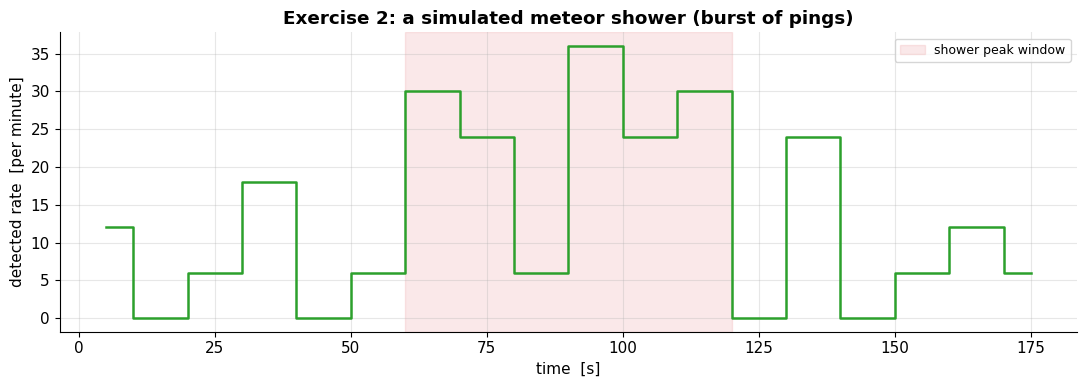

total detected over the 'night': 40  (true 64)


In [12]:
# Exercise 2: a shower = a burst of high rate sandwiched by quiet background.
seg = 60.0  # seconds per segment
rates = (8.0, 50.0, 8.0)  # quiet / SHOWER PEAK / quiet
all_times, all_power, all_pings, offset = [], [], [], 0.0
for i, r in enumerate(rates):
    tms, pwr, tp = meteor.simulate_meteor_timeseries(
        duration_s=seg, rate_per_min=r, sample_rate=100.0,
        noise=1.0, seed=SEED + i,
    )
    all_times.append(tms + offset)
    all_power.append(pwr)
    all_pings.append(tp + offset)
    offset += seg

times_s = np.concatenate(all_times)
power_s = np.concatenate(all_power)
pings_s = np.concatenate(all_pings)
det_s = meteor.detect_pings(times_s, power_s, threshold=6.0, min_separation_s=0.3)

edges = np.arange(0, offset + 10, 10.0)
hist, _ = np.histogram(det_s.times, bins=edges)
ctr = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(ctr, hist * (60.0 / 10.0), where="mid", color="#2ca02c", lw=1.8)
ax.axvspan(seg, 2 * seg, color="#d62728", alpha=0.10, label="shower peak window")
ax.set_xlabel("time  [s]")
ax.set_ylabel("detected rate  [per minute]")
ax.set_title("Exercise 2: a simulated meteor shower (burst of pings)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
print(f"total detected over the 'night': {det_s.count}  (true {pings_s.size})")

<details><summary>Solution</summary>

The starter is the worked answer: concatenate three `simulate_meteor_timeseries` segments (quiet / peak / quiet), shifting each segment's time axis and its ping times by a running `offset` so the three records join seamlessly, then bin the detections into a rate curve. Using a different `seed` per segment (`SEED + i`) avoids stitching three identical realisations together.

```python
seg = 60.0
rates = (8.0, 50.0, 8.0)  # quiet / SHOWER PEAK / quiet
all_times, all_power, all_pings, offset = [], [], [], 0.0
for i, r in enumerate(rates):
    tms, pwr, tp = meteor.simulate_meteor_timeseries(
        duration_s=seg, rate_per_min=r, sample_rate=100.0, noise=1.0, seed=SEED + i)
    all_times.append(tms + offset); all_power.append(pwr); all_pings.append(tp + offset)
    offset += seg
times_s, power_s, pings_s = map(np.concatenate, (all_times, all_power, all_pings))
det_s = meteor.detect_pings(times_s, power_s, threshold=6.0, min_separation_s=0.3)
```

Expected: the detected-rate step curve is low (~8/min) in the outer thirds and spikes sharply inside the shaded middle minute (~50/min) — exactly the shape of a real shower peak. **Takeaway:** the contributable product is this rate-vs-time curve, and a shower shows up as a clear burst above the quiet background.

</details>

### Exercise 3 — Estimate the decay time of an echo

The underdense decay time $\tau$ encodes the trail's altitude (via the diffusion
coefficient $D$). Make a single clean underdense echo with `underdense_echo`, then
**recover** $\tau$ by fitting a straight line to $\ln A$ vs $t$ on the decaying
part — the slope is $-1/\tau$. Confirm you get back the value you put in.

true tau     : 0.250 s
recovered tau: 0.250 s


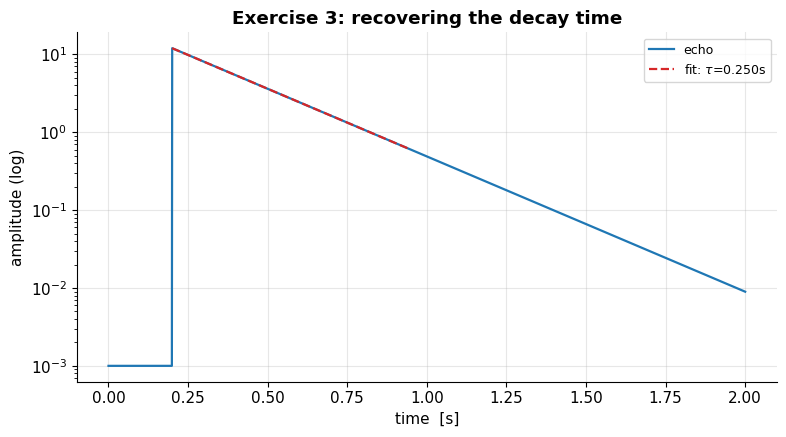

In [13]:
# Exercise 3: recover tau from an underdense echo by log-linear fitting.
t_e = np.linspace(0, 2.0, 2000)
TRUE_TAU = 0.25
echo = meteor.underdense_echo(t_e, t0=0.2, amplitude=12.0, decay_time=TRUE_TAU)

# Fit only the decaying part, well above the (here zero) floor.
mask = (t_e > 0.2) & (echo > 0.05 * echo.max())
slope, intercept = np.polyfit(t_e[mask] - 0.2, np.log(echo[mask]), 1)
tau_fit = -1.0 / slope

print(f"true tau     : {TRUE_TAU:.3f} s")
print(f"recovered tau: {tau_fit:.3f} s")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(t_e, np.clip(echo, 1e-3, None), color="#1f77b4", lw=1.6, label="echo")
ax.semilogy(t_e[mask], np.exp(intercept + slope * (t_e[mask] - 0.2)),
            color="#d62728", ls="--", lw=1.6, label=fr"fit: $\tau$={tau_fit:.3f}s")
ax.set_xlabel("time  [s]")
ax.set_ylabel("amplitude (log)")
ax.set_title("Exercise 3: recovering the decay time")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# TODO: add noise to the echo (echo += rng.normal(0, 0.3, echo.size)) and see how
#       the recovered tau degrades -- real fits need the noise floor handled.

<details><summary>Solution</summary>

The clean fit in the starter recovers $\tau$ exactly because $\ln A$ is perfectly linear in $t$ for an underdense echo. The `# TODO` asks what noise does: add Gaussian noise, and the recovered $\tau$ is biased **high**, because near the tail the noise floor stops the curve from falling, flattening the apparent slope ($-1/\tau$) — the classic reason real fits must mask out or model the noise floor before taking the log.

```python
rng = signals.rng(SEED)
for noise_sigma in (0.0, 0.1, 0.3):
    echo_n = meteor.underdense_echo(t_e, t0=0.2, amplitude=12.0, decay_time=TRUE_TAU)
    echo_n = echo_n + rng.normal(0, noise_sigma, echo_n.size)
    mask = (t_e > 0.2) & (echo_n > 0.05 * echo_n.max())
    slope, _ = np.polyfit(t_e[mask] - 0.2, np.log(np.clip(echo_n[mask], 1e-6, None)), 1)
    print(f"noise={noise_sigma:.1f} -> tau_fit={-1.0/slope:.3f} s  (true {TRUE_TAU:.3f})")
```

Expected: `tau_fit` ≈ 0.250 at zero noise, ~0.255 at $\sigma=0.1$, and ~0.34 at $\sigma=0.3$ — the bias grows with noise and always **over**-estimates $\tau$. **Takeaway:** log-linear fitting recovers the decay time cleanly only above the noise floor; with real, noisy pings you must restrict the fit to high-SNR samples (or fit the amplitude directly) to avoid biasing $\tau$ upward.

</details>

## Recap

- **Forward meteor scatter** reflects a *below-horizon* transmitter off a
  meteor's ionised trail, producing a short **ping** in your receiver. It's the
  cheapest real radio astronomy there is — an RTL-SDR plus a wire, aimed off
  **GRAVES (143.050 MHz)** in Europe or a distant **FM carrier** worldwide.
- Pings come in two flavours: **underdense** (instant rise, exponential decay set
  by ambipolar diffusion — `underdense_echo`) and **overdense** (a longer ragged
  plateau from a dense, metallic-like trail — `overdense_echo`).
- `simulate_meteor_timeseries` builds a realistic noisy record with Poisson-random
  pings; the same events appear as bright dashes in the
  [Chapter 5](05_sdr_basics.ipynb) **spectrogram**.
- `detect_pings` (returning a `MeteorDetection`) counts pings by **MAD-robust
  thresholding**. The threshold is a **sensitivity vs false-alarm** trade-off; the
  scientific product is not one count but the **meteor rate** over a night or
  shower, which amateurs contribute to the IMO/RMOB networks.
- **Passive radar** generalises the idea: cross-correlate a **reference** and a
  **surveillance** channel to get a target's **range and Doppler** from a
  transmitter you don't control — the realm of **[`blah2`](https://github.com/30hours/blah2)**
  ([Field Notes](../docs/field-notes.md)).

## What's next

This was an optional hardware side-quest off the main interferometry arc. The
coherence problem behind passive radar's two channels is the same one that makes
real interferometry hard — picked up in
[Chapter 17 (Coherent Interferometry with KrakenSDR)](17_coherent_interferometry_kraken.ipynb)
and the [Field Notes](../docs/field-notes.md). For more buildable projects — IBT,
hydrogen-line horns, VLF, and the meteor and passive-radar hacks above — see
[`docs/projects.md`](../docs/projects.md). And it is always legal to just
**listen**: tune a [WebSDR](http://websdr.org/) right now and, if you're in
Europe, see if you can catch a GRAVES ping yourself.